In [2]:
from Bern3D import *
from DiffSim import *
import numpy as np
import numba
from numba.typed import List
numba.set_num_threads(4)
rng = np.random.default_rng()

In [12]:
one_dim = Bern3Diff(theta=0.5, cost=-.001, sigma=(0.55,0.55), pvalid=1.0, task_prior=1.0, sample_actions=List([List(['x1'])]), state_range=20)

337


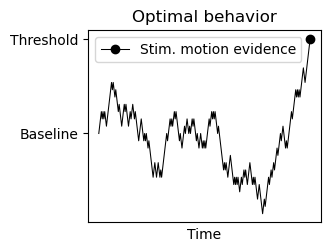

In [231]:
diffsim = DiffSim(one_dim, (True, True))
fig, ax = plt.subplots(figsize=(3,2.5))
for i in range(1):
    path = sample_diff_path(diffsim)
    t = np.linspace(0, path.shape[1]-1, path.shape[1])
    ax.plot(t, path[1,:], color='black', markevery=[-1], marker='o', label="Stim. motion evidence", linewidth=0.75)

ax.set_xticks([])
ax.set_xlabel("Time")
ax.set_yticks([13,0], labels=["Threshold", "Baseline"])
ax.legend()
ax.set_title("Optimal behavior")
plt.savefig("ex1.pdf")

In [60]:
three_dim = Bern3Diff(theta=0.5, cost=-.01, sigma=(0.65,0.65), pvalid=1.0, task_prior=1.0, sample_actions=List([List(['x1'])]), state_range=20)

43


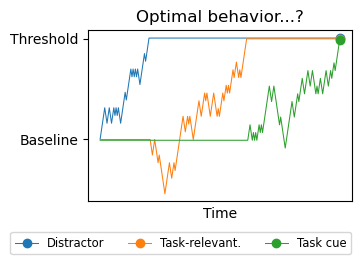

In [260]:

sample_diff_path(diffsim)
path1 = sample_diff_path(diffsim)[1,:]
path2 = np.append(np.zeros_like(path1), sample_diff_path(diffsim)[1,:])
path3 = np.append(np.zeros_like(path2), sample_diff_path(diffsim)[1,:])

path1 = np.append(path1,np.repeat(path1[-1], len(path3)-len(path1)))
path2 = np.append(path2,np.repeat(path2[-1], len(path3)-len(path2)))
t = np.linspace(0, len(path3)-1, len(path3))

fig, ax = plt.subplots(figsize=(3.5,2.5), layout="constrained")
ax.plot(t, path1+0.1, markevery=[-1], marker='o', label="Distractor", linewidth=0.75)
ax.plot(t, path2, markevery=[-1], marker='o', label='Task-relevant.', linewidth=0.75)
ax.plot(t, path3-0.1, markevery=[-1], marker='o', label='Task cue', linewidth=0.75)
fig.legend(loc="outside lower center", ncols=3, fontsize="small")

ax.set_xticks([])
ax.set_xlabel("Time")
ax.set_title("Optimal behavior...?")
ax.set_yticks([13,0], labels=["Threshold", "Baseline"])
plt.savefig("ex2.pdf")


In [58]:
two_dim_certain = Bern3Diff(theta=0.5, cost=-.001, sigma=(0.75,0.75), pvalid=1.0, task_prior=1.0, sample_actions=List([List(['x0','x1'])]), state_range=30)

45


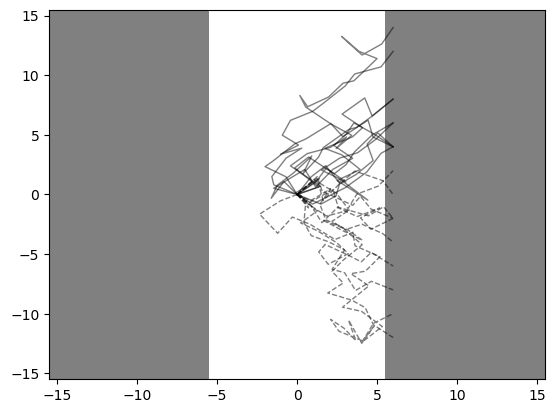

In [44]:
vr = 15
sr = two_dim_certain.state_range
vstart = sr-vr
vstop = sr+vr+1
Y = two_dim_certain.get_sample_region()[:,:,sr]
Y = Y[vstart:vstop, vstart:vstop]
x = np.arange(-vr, vr+1)
fig, ax = plt.subplots()
ax.pcolormesh(x, x, Y, cmap='gray', vmin=-1)

for t in range(10):
    diffsim = DiffSim(two_dim_certain, (False, True))
    path = sample_diff_path(diffsim)
    path[:,1:path.shape[1]-1] = path[:,1:path.shape[1]-1] + rng.uniform(-.5, .5, size=(3,path.shape[1]-2))
    ax.plot(path[1,:], path[0,:], color='black', linewidth=1, alpha=.5, linestyle='--')

for t in range(10):
    diffsim = DiffSim(two_dim_certain, (True, True))
    path = sample_diff_path(diffsim)
    path[:,1:path.shape[1]-1] = path[:,1:path.shape[1]-1] + rng.uniform(-.5, .5, size=(3,path.shape[1]-2))
    ax.plot(path[1,:], path[0,:], color='black', linewidth=1, alpha=.5)
